In [1]:
import pandas as  pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as  sns

df=pd.read_csv(r'C:\Users\riyas\OneDrive\Desktop\Credit_Risk_project\data\train.csv')
print(df.shape)
print(df['default'].value_counts())
print(df.dtypes.value_counts())

(9000, 122)
default
0    8313
1     687
Name: count, dtype: int64
float64    65
int64      41
str        16
Name: count, dtype: int64


In [2]:
import os
os.listdir(r'C:\Users\riyas\OneDrive\Desktop\Credit_Risk_project')

['data', 'notebook', 'output', 'Visuals']

In [3]:
os.listdir(r'C:\Users\riyas\OneDrive\Desktop\Credit_Risk_project\data')

['train.csv']

In [4]:
print(df.columns.tolist())

['SK_ID_CURR', 'default', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'EL

In [5]:
#missing value analysis
missing= df.isnull().sum()
missing_pct= (missing/len(df))*100
missing_df=pd.DataFrame({'missing_count': missing,
                         'missing_pct': missing_pct})
missing_df= missing_df[missing_df['missing_count']> 0].sort_values(
    'missing_pct', ascending= False)
print(missing_df.head(20))

                          missing_count  missing_pct
COMMONAREA_AVG                     6209    68.988889
COMMONAREA_MODE                    6209    68.988889
COMMONAREA_MEDI                    6209    68.988889
NONLIVINGAPARTMENTS_AVG            6172    68.577778
NONLIVINGAPARTMENTS_MODE           6172    68.577778
NONLIVINGAPARTMENTS_MEDI           6172    68.577778
FONDKAPREMONT_MODE                 6097    67.744444
LIVINGAPARTMENTS_MODE              6076    67.511111
LIVINGAPARTMENTS_AVG               6076    67.511111
LIVINGAPARTMENTS_MEDI              6076    67.511111
FLOORSMIN_MEDI                     6050    67.222222
FLOORSMIN_AVG                      6050    67.222222
FLOORSMIN_MODE                     6050    67.222222
OWN_CAR_AGE                        5937    65.966667
YEARS_BUILD_MODE                   5918    65.755556
YEARS_BUILD_AVG                    5918    65.755556
YEARS_BUILD_MEDI                   5918    65.755556
LANDAREA_MEDI                      5232    58.

In [6]:
#checking if missing ownage car correlates w default
df['car_age_missing']= df['OWN_CAR_AGE'].isnull().astype(int)
print(df.groupby('car_age_missing')['default'].mean())

#checking i fmissing occupationtype correlates w default
df['occupation_missing'] = df['OCCUPATION_TYPE'].isnull().astype(int)
print(df.groupby('occupation_missing')['default'].mean())

#checking if missing exts3 correlates w default
df['ext3_missing'] = df['EXT_SOURCE_3'].isnull().astype(int)
print(df.groupby('ext3_missing')['default'].mean())


car_age_missing
0    0.075743
1    0.076638
Name: default, dtype: float64
occupation_missing
0    0.086801
1    0.053722
Name: default, dtype: float64
ext3_missing
0    0.072105
1    0.093062
Name: default, dtype: float64


C:\Users\riyas\AppData\Local\Temp\ipykernel_27812\3808278616.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['car_age_missing']= df['OWN_CAR_AGE'].isnull().astype(int)
C:\Users\riyas\AppData\Local\Temp\ipykernel_27812\3808278616.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['occupation_missing'] = df['OCCUPATION_TYPE'].isnull().astype(int)
C:\Users\riyas\AppData\Local\Temp\ipykernel_27812\3808278616.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` ma

C:\Users\riyas\AppData\Local\Temp\ipykernel_27812\4151145176.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='default', data=df , palette=['#27ae60','#c0392b'])


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\riyas\\OneDrive\\Desktop\\Credit_Risk_project\\output\\Visuals\\01_class_distribution.png'

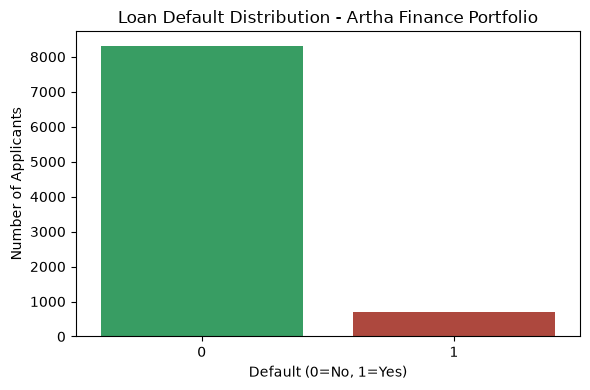

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='default', data=df , palette=['#27ae60','#c0392b'])
plt.title('Loan Default Distribution - Artha Finance Portfolio')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('Number of Applicants')
plt.tight_layout()
plt.savefig(r'C:\Users\riyas\OneDrive\Desktop\Credit_Risk_project\output\Visuals\01_class_distribution.png', dpi=150)
plt.show()


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='default', data=df, palette=['#27ae60','#c0392b'])
plt.title('Loan Default Distribution — Artha Finance Portfolio')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('Number of Applicants')
plt.tight_layout()
plt.savefig(r'C:\Users\riyas\OneDrive\Desktop\Credit_Risk_project\Visuals\01_class_distribution.png', dpi=150)
plt.show()

In [ ]:
print(f"Default rate: {df['default'].mean():.2%}")

In [ ]:
#vis1
df['INCOME_BRACKET']= pd.cut(df['AMT_INCOME_TOTAL'],
                              bins=[0, 100000,200000, 400000, float('inf')],
                              labels=['<1L','1-2L','2-4L', '4L+'])
default_by_income = df.groupby('INCOME_BRACKET', observed=True)['default'].mean()

plt.figure(figsize=(8,5))
default_by_income.plot(kind='bar', color='#c0392b', edgecolor='black')
plt.title('Default Rate by Annual Income Bracket — Artha Finance')
plt.xlabel('Annual Income (₹)')
plt.ylabel('Default Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(r'C:\Users\riyas\OneDrive\Desktop\Credit_Risk_project\Visuals\02_default_by_income.png', dpi=150)
plt.show()

In [ ]:
#vis2
emp_default = df.groupby('NAME_INCOME_TYPE')['default'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
emp_default.plot(kind='bar', color='#2980b9', edgecolor='black')
plt.title('Default Rate by Employment Type — Artha Finance')
plt.ylabel('Default Rate')
plt.xlabel('Employment Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r'C:\Users\riyas\OneDrive\Desktop\Credit_Risk_project\Visuals\03_default_by_employment.png', dpi=150)
plt.show()


In [ ]:
# Visual 3: Loan to income ratio by default status
df['LOAN_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

plt.figure(figsize=(10,5))
sns.boxplot(x='default', y='LOAN_INCOME_RATIO', data=df,
            showfliers=False, palette=['#27ae60', '#c0392b'])
plt.title('Loan-to-Income Ratio: Defaulters vs Non-Defaulters — Artha Finance')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('Loan to Income Ratio')
plt.tight_layout()
plt.savefig(r'C:\Users\riyas\OneDrive\Desktop\Credit_Risk_project\Visuals\04_loan_income_ratio.png', dpi=150)
plt.show()

In [ ]:
# Visual 4: Age distribution by default status
df['AGE_YEARS'] = abs(df['DAYS_BIRTH']) / 365

plt.figure(figsize=(10,5))
df[df['default']==0]['AGE_YEARS'].hist(bins=40, alpha=0.6, 
                                        label='Non-Default', color='#27ae60')
df[df['default']==1]['AGE_YEARS'].hist(bins=40, alpha=0.6, 
                                        label='Default', color='#c0392b')
plt.title('Age Distribution: Defaulters vs Non-Defaulters — Artha Finance')
plt.xlabel('Age (Years)')
plt.ylabel('Number of Applicants')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\riyas\OneDrive\Desktop\Credit_Risk_project\Visuals\05_age_distribution.png', dpi=150)
plt.show()

In [ ]:
# Visual 5: External credit score distribution
plt.figure(figsize=(10,5))
sns.kdeplot(df[df['default']==0]['EXT_SOURCE_2'].dropna(), 
            label='Non-Default', color='#27ae60', fill=True, alpha=0.4)
sns.kdeplot(df[df['default']==1]['EXT_SOURCE_2'].dropna(), 
            label='Default', color='#c0392b', fill=True, alpha=0.4)
plt.title('External Credit Score Distribution by Default Status — Artha Finance')
plt.xlabel('External Credit Score (EXT_SOURCE_2)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\riyas\OneDrive\Desktop\Credit_Risk_project\Visuals\06_credit_score_dist.png', dpi=150)
plt.show()


In [ ]:
# Visual 6: Default rate by family status
family_default = df.groupby('NAME_FAMILY_STATUS')['default'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
family_default.plot(kind='bar', color='#8e44ad', edgecolor='black')
plt.title('Default Rate by Family Status — Artha Finance')
plt.ylabel('Default Rate')
plt.xlabel('Family Status')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r'C:\Users\riyas\OneDrive\Desktop\Credit_Risk_project\Visuals\07_family_status.png', dpi=150)
plt.show()


In [ ]:
# Visual 7: Default rate by contract type
contract_default = df.groupby('NAME_CONTRACT_TYPE')['default'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
contract_default.plot(kind='bar', color='#e67e22', edgecolor='black')
plt.title('Default Rate by Contract Type — Artha Finance')
plt.ylabel('Default Rate')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(r'C:\Users\riyas\OneDrive\Desktop\Credit_Risk_project\Visuals\08_contract_type.png', dpi=150)
plt.show()


In [ ]:
# Visual 8: Days employed vs default (fixing the 365243 anomaly first)
df_emp = df[df['DAYS_EMPLOYED'] != 365243].copy()
df_emp['YEARS_EMPLOYED'] = abs(df_emp['DAYS_EMPLOYED']) / 365

plt.figure(figsize=(10,5))
sns.boxplot(x='default', y='YEARS_EMPLOYED', data=df_emp,
            showfliers=False, palette=['#27ae60', '#c0392b'])
plt.title('Years Employed: Defaulters vs Non-Defaulters — Artha Finance')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('Years in Current Employment')
plt.tight_layout()
plt.savefig(r'C:\Users\riyas\OneDrive\Desktop\Credit_Risk_project\Visuals\09_employment_years.png', dpi=150)
plt.show()
